<a href="https://colab.research.google.com/github/and1915/minuevorepo/blob/main/TF_GuevaraAndrea.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Trabajo Final del curso Python para las CCSS: Libertad de opinión e Ideología política**

Autora: Andrea Guevara

In [14]:
pip install pandas

In [15]:
pip install pyreadstat

In [16]:
import pyreadstat

In [42]:
import requests


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [90]:
url = "https://raw.githubusercontent.com/and1915/minuevorepo/main/Latinobarometro_2023_Esp_Spss_v1_0.sav"


In [91]:
response = requests.get(url)
with open("Latinobarometro_2023.sav", "wb") as file:
    file.write(response.content)

In [92]:
df, meta = pyreadstat.read_sav("Latinobarometro_2023.sav")


**Limpieza de datos**

Seleccionar variables

In [93]:
df = df[['P16ST', 'P49ST']]

Adecuar y agrupar etiquetas

In [94]:
def agrupar_ideologia(valor):
    try:
        valor = int(valor)
        if valor <= 3:
            return 'Izquierda'
        elif 4 <= valor <= 6:
            return 'Centro'
        elif valor >= 7:
            return 'Derecha'
        else:
            return 'No responde'
    except ValueError:
        return 'No responde'

df['Ideología'] = df['P16ST'].apply(agrupar_ideologia)

In [103]:
def transformar_respuesta(valor):
    if valor == 1:
        return 'Sí'
    elif valor == 2:
        return 'No'
    else:
        return 'No responde'

Quitar NAs

In [96]:
df = df[(df['Ideología'] != 'No responde')]

In [104]:
df = df[df['P49ST'] != 'No responde']

**P16ST - Ideología Política**

Tabla de frecuencias

In [98]:
frecuencias5 = df.value_counts("Ideología", sort = False)

porcentajes5 = df.value_counts("Ideología", sort = False, normalize=True) * 100

tabla_frecuencias5 = pd.DataFrame({
    'Frecuencia': frecuencias5,
    'Porcentaje (%)': porcentajes5
})

tabla_frecuencias5.index.name = 'Respuesta'
tabla_frecuencias5.columns.name = 'Ideología Política'

print(tabla_frecuencias5)

Ideología Política  Frecuencia  Porcentaje (%)
Respuesta                                     
Centro                    6891       38.306743
Derecha                   7066       39.279560
Izquierda                 4032       22.413697


Gráfico

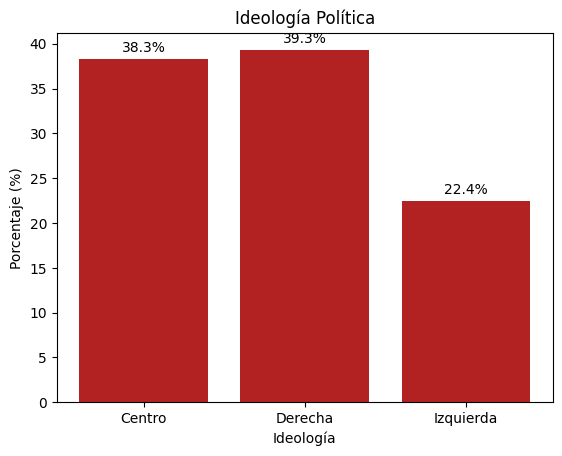

In [99]:
plt.bar(porcentajes5.index, porcentajes5.values, color='firebrick')

plt.title("Ideología Política")
plt.xlabel("Ideología")
plt.ylabel("Porcentaje (%)")

for i, value in enumerate(porcentajes5.values):
    plt.text(porcentajes5.index[i], value + 0.5, f'{value:.1f}%', ha='center', va='bottom')

plt.show()

**P49ST - No poder opinar libremente**


Tabla de Frecuencias

In [105]:
frecuencias = df.value_counts("P49ST", sort = False)

porcentajes = df.value_counts("P49ST", sort = False, normalize=True) * 100

tabla_frecuencias = pd.DataFrame({
    'Frecuencia': frecuencias,
    'Porcentaje (%)': porcentajes
})

tabla_frecuencias.index.name = 'Respuesta'
tabla_frecuencias.columns.name = 'Percepción de no poder opinar libremente'

print(tabla_frecuencias)

Percepción de no poder opinar libremente  Frecuencia  Porcentaje (%)
Respuesta                                                           
No                                              7268       41.652817
Sí                                             10181       58.347183


Gráfico

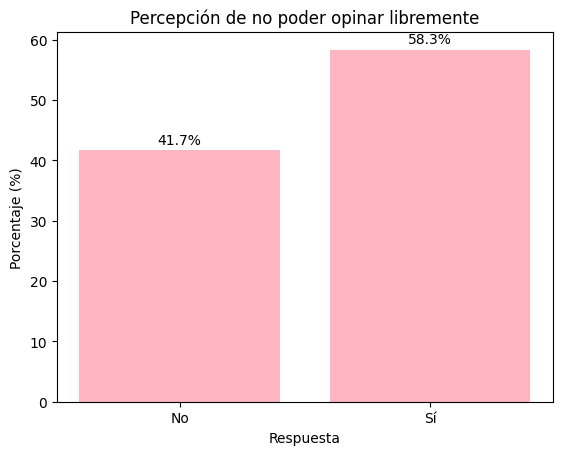

In [106]:
plt.bar(porcentajes.index, porcentajes.values, color='lightpink')

plt.title("Percepción de no poder opinar libremente")
plt.xlabel("Respuesta")
plt.ylabel("Porcentaje (%)")

for i, value in enumerate(porcentajes.values):
    plt.text(porcentajes.index[i], value + 0.5, f'{value:.1f}%', ha='center', va='bottom')

plt.show()


**Percepción de no poder opinar libremente según Ideología Política**

Tabla cruzada

In [107]:
 pd.crosstab(df['Ideología'], df['P49ST'], normalize= "all")*100

P49ST,No,Sí
Ideología,,
Centro,16.167116,22.339389
Derecha,16.453665,22.539974
Izquierda,9.032036,13.467821


In [108]:
crosstab_result = pd.crosstab(df['P49ST'], df['Ideología'], normalize= "all")*100
crosstab_result.describe().T

,count,mean,std,min,25%,50%,75%,max
Ideología,,,,,,,,
Centro,2.0,19.253252,4.364456,16.167116,17.710184,19.253252,20.796321,22.339389
Derecha,2.0,19.496819,4.303670,16.453665,17.975242,19.496819,21.018396,22.539974
Izquierda,2.0,11.249928,3.136573,9.032036,10.140982,11.249928,12.358874,13.467821


Gráfico

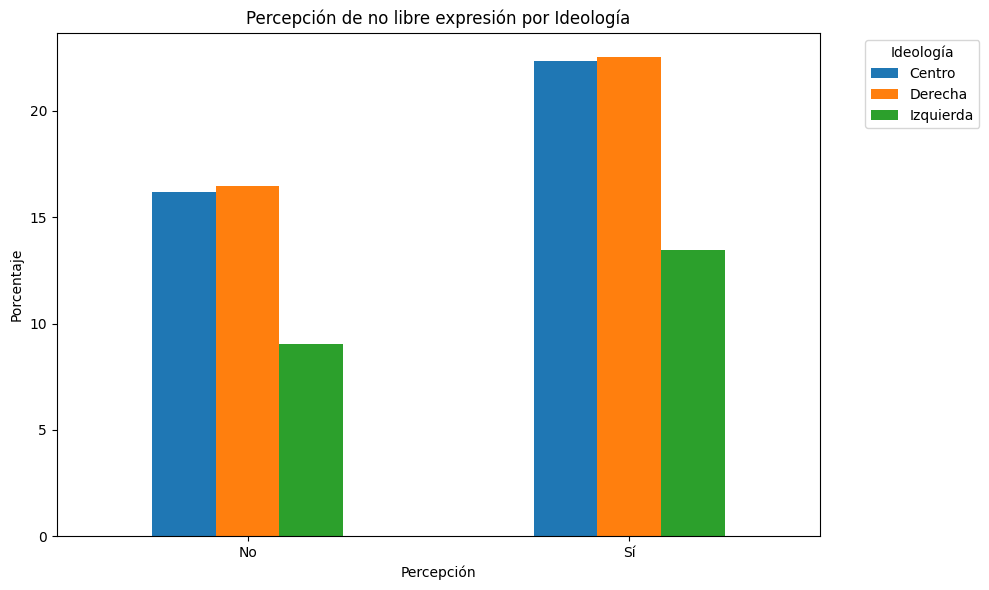

In [109]:
crosstab_result.plot(kind='bar', figsize=(10, 6))
plt.title('Percepción de no libre expresión por Ideología')
plt.xlabel('Percepción')
plt.ylabel('Porcentaje')
plt.xticks(rotation=0)
plt.legend(title='Ideología', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()